In [1]:
import pandas as pd

dataset = pd.read_csv("compounds_predicted_pathways.csv")
dataset["Pathways"] = dataset["Pathways"].fillna("NA")
dataset["Pathways"] = dataset["Pathways"].apply(lambda x: '>1 class' if len(x.split(',')) > 1 else x)
dataset["Pathways"] = dataset["Pathways"].astype(str)

/home/jcapela/miniforge3/envs/esp/lib/python3.11/site-packages/rdkit/Chem/Draw/IPythonConsole.py:261: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


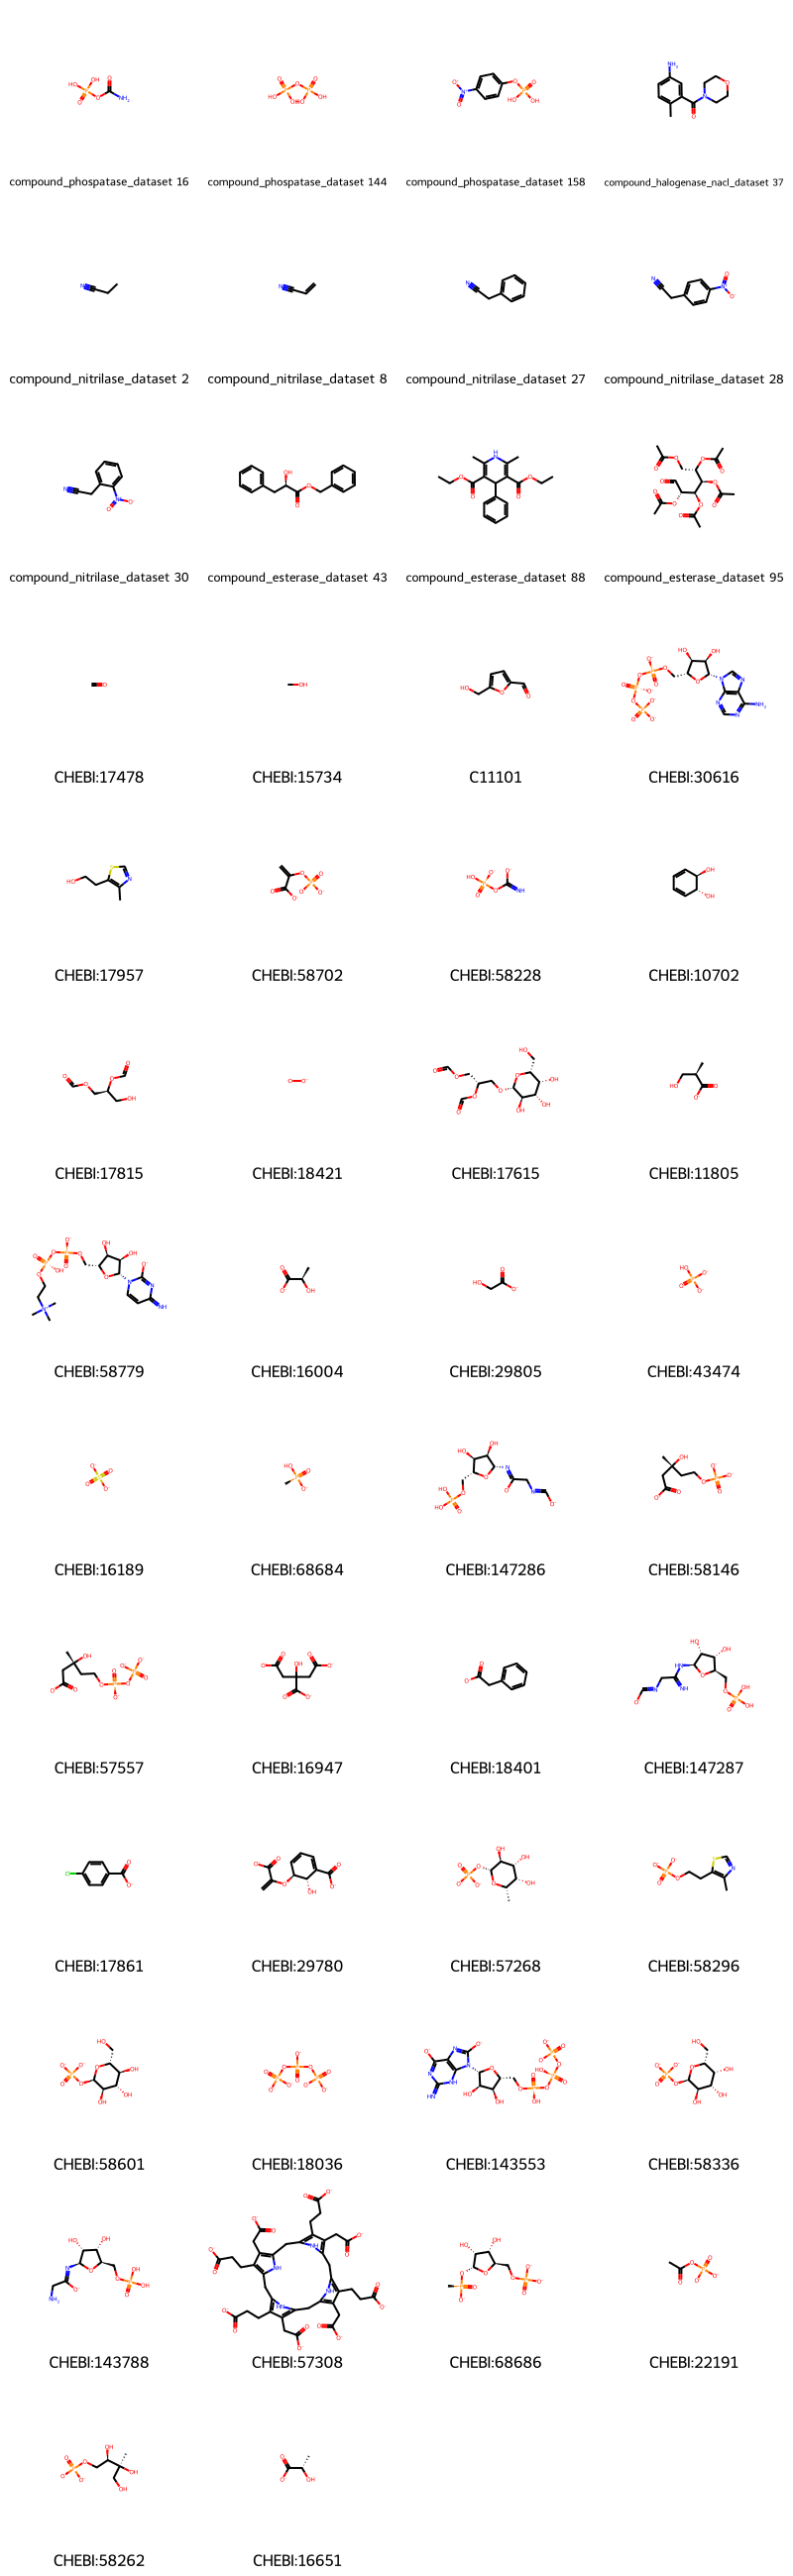

In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

# Filter molecules with "NA" pathways
na_molecules = dataset[dataset["Pathways"] == "NA"]

# Function to draw molecules
def draw_molecules(smiles_list, mol_ids):
    mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
    img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=mol_ids)
    return img

# Assuming the dataset has a column named "SMILES" for SMILES strings and "ID" for molecule IDs
smiles_list = na_molecules["SMILES"].tolist()
mol_ids = na_molecules["ID"].tolist()

# Draw the molecules
img = draw_molecules(smiles_list, mol_ids)

# Display the image
img

In [3]:
na_molecules.shape

(133, 5)

In [4]:
dataset["Pathways"]

0              Amino acids and Peptides
1              Amino acids and Peptides
2                              >1 class
3                              >1 class
4                              >1 class
                     ...               
1723    Shikimates and Phenylpropanoids
1724    Shikimates and Phenylpropanoids
1725                          Alkaloids
1726                          Alkaloids
1727    Shikimates and Phenylpropanoids
Name: Pathways, Length: 1728, dtype: object

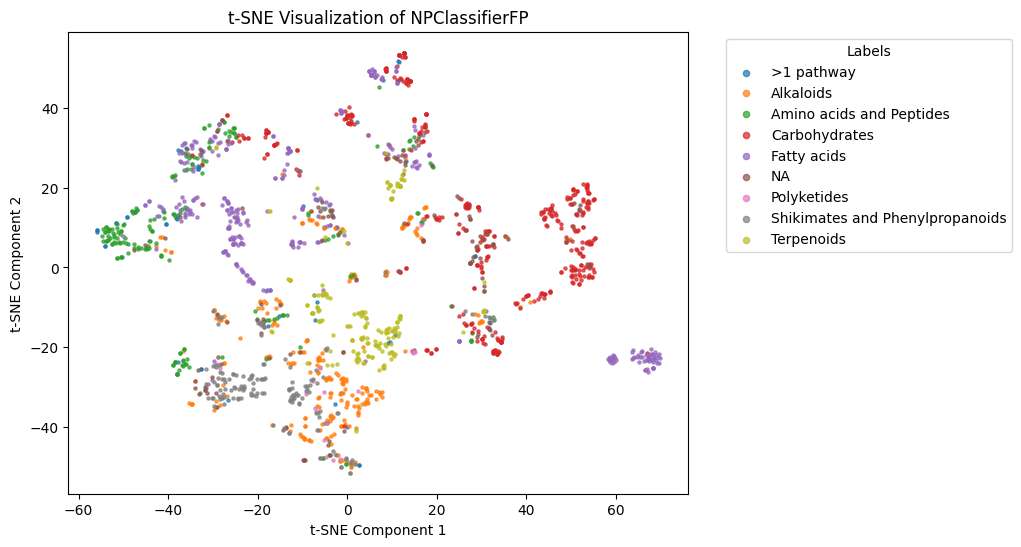

In [ ]:
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def generate_unsupervised_learning_molecular_similarities(dataset, smiles_field, method=TSNE(n_components=2, random_state=42)):
    # Create a function to compute molecular fingerprints
    def compute_fingerprint(smiles):
        molecule = Chem.MolFromSmiles(smiles)
        fingerprint = AllChem.GetMorganFingerprintAsBitVect(molecule, 2, nBits=1024)
        return fingerprint

    # Compute molecular fingerprints for each molecule in the combined dataset
    fingerprints = [compute_fingerprint(smiles) for smiles in dataset.loc[:, smiles_field]]

    similarity_matrix = np.zeros((len(fingerprints), len(fingerprints)))
    # Compute molecular similarities using Tanimoto coefficient
    for i in range(len(fingerprints)):
        for j in range(i + 1, len(fingerprints)):
            similarity = DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j])
            similarity_matrix[i, j] = similarity
            similarity_matrix[j, i] = similarity

    # Apply t-SNE to reduce the dimensionality
    tsne_embeddings = method.fit_transform(similarity_matrix)
    # Separate the embeddings based on the original datasets
    dataset[f"{method.__class__.__name__} 1"] = tsne_embeddings[:, 0]
    dataset[f"{method.__class__.__name__} 2"] = tsne_embeddings[:, 1]

    return dataset


tsne = TSNE(n_components=2, random_state=42)
dataset = pd.read_csv("compounds_predicted_pathways.csv")
dataset["Pathways"] = dataset["Pathways"].fillna("NA")
dataset["Pathways"] = dataset["Pathways"].apply(lambda x: '>1 pathway' if len(x.split(',')) > 1 else x)
dataset["Pathways"] = dataset["Pathways"].astype(str)
tsne_ = generate_unsupervised_learning_molecular_similarities(dataset, "SMILES", tsne)


import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming `dataset` and `tsne_` are already defined
# Define unique colors for each class
unique_labels = np.unique(dataset.Pathways)

# Plot with discrete colors
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(dataset.Pathways) == str(label))[0]
    plt.scatter(tsne_.loc[idx, f"{tsne.__class__.__name__} 1"], tsne_.loc[idx, f"{tsne.__class__.__name__} 2"], label=label, alpha=0.7, s=5)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization of NPClassifierFP")
# Add a legend with bigger markers and place it outside the plot
plt.legend(title="Labels", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('compounds_latent_space.png', format='PNG', dpi=200, bbox_inches='tight', transparent=True)
plt.show()


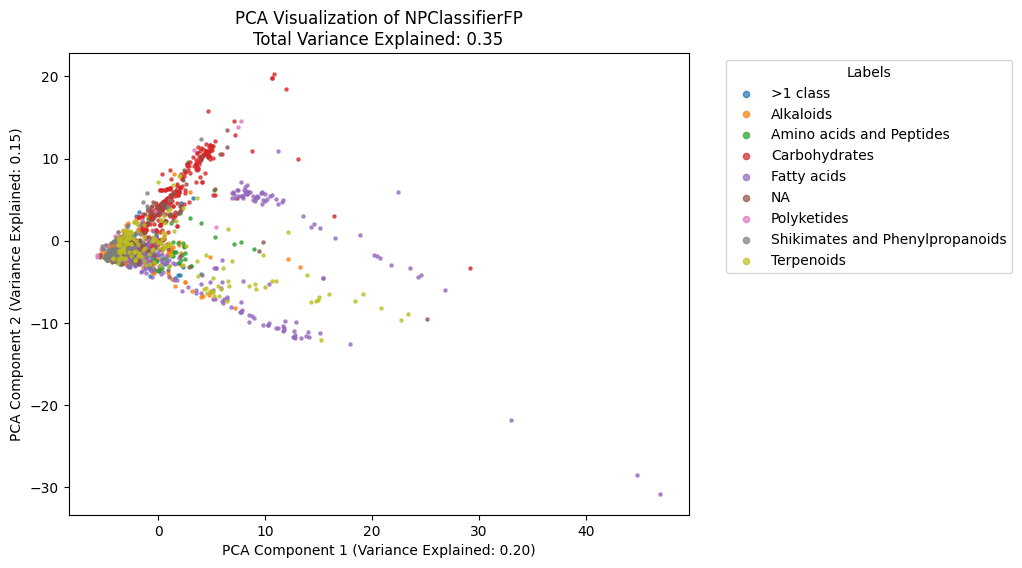

In [5]:
from plants_sm.io.pickle import read_pickle
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

def generate_unsupervised_learning_np_classifier(dataset, features, method=TSNE(n_components=2, random_state=42)):
    features_array = []
    for i, row in dataset.iterrows():
        id_ = row["ID"]
        features_array.append(features[id_])
    features_array = np.array(features_array)
    embeddings = method.fit_transform(features_array)
    dataset[f"{method.__class__.__name__} 1"] = embeddings[:, 0]
    dataset[f"{method.__class__.__name__} 2"] = embeddings[:, 1]
    return dataset, method  # Return the method object as well

dataset = pd.read_csv("compounds_predicted_pathways.csv")
dataset["Pathways"] = dataset["Pathways"].fillna("NA")
dataset["Pathways"] = dataset["Pathways"].apply(lambda x: '>1 class' if len(x.split(',')) > 1 else x)
dataset["Pathways"] = dataset["Pathways"].astype(str)
np_classifier_features = read_pickle("../dataset_integration/features_compounds_np_classifier_fp/features.pkl")["ligands"]

pca = PCA(n_components=2)
pca_, pca_model = generate_unsupervised_learning_np_classifier(dataset, np_classifier_features, method=pca)

# Get the explained variance ratio
explained_variance = pca_model.explained_variance_ratio_

# Plot
plt.figure(figsize=(8, 6))
unique_labels = np.unique(dataset.Pathways)
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(dataset.Pathways) == str(label))[0]
    plt.scatter(pca_.loc[idx, f"{pca.__class__.__name__} 1"],
                pca_.loc[idx, f"{pca.__class__.__name__} 2"],
                label=label, alpha=0.7, s=5)

plt.xlabel(f"PCA Component 1 (Variance Explained: {explained_variance[0]:.2f})")
plt.ylabel(f"PCA Component 2 (Variance Explained: {explained_variance[1]:.2f})")
plt.title(f"PCA Visualization of NPClassifierFP\nTotal Variance Explained: {sum(explained_variance):.2f}")
plt.legend(title="Labels", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('compounds_latent_space_PCA.png', format='PNG', dpi=200, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:
from plants_sm.io.pickle import read_pickle
dataset = pd.read_csv("compounds_predicted_pathways.csv")
dataset["Pathways"] = dataset["Pathways"].fillna("NA")
dataset["Pathways"] = dataset["Pathways"].apply(lambda x: '>1 class' if len(x.split(',')) > 1 else x)
dataset["Pathways"] = dataset["Pathways"].astype(str)
np_classifier_features = read_pickle("../dataset_integration/features_compounds_np_classifier_fp/features.pkl")["ligands"]

tsne_ = generate_unsupervised_learning_np_classifier(dataset, np_classifier_features)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Assuming `dataset` and `tsne_` are already defined
# Define unique colors for each class
unique_labels = np.unique(dataset.Pathways)

# Plot with discrete colors
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    idx = np.where(np.array(dataset.Pathways) == str(label))[0]
    plt.scatter(tsne_.loc[idx, f"{tsne.__class__.__name__} 1"], tsne_.loc[idx, f"{tsne.__class__.__name__} 2"], label=label, alpha=0.7, s=5)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of NPClassifierFP")
# Add a legend with bigger markers and place it outside the plot
plt.legend(title="Labels", markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('compounds_latent_space.png', format='PNG', dpi=200, bbox_inches='tight', transparent=True)
plt.show()

In [9]:
import pandas as pd

dataset = pd.read_csv("compounds_predicted_pathways.csv")
dataset["Pathways"] = dataset["Pathways"].fillna("NA")
dataset["Pathways"] = dataset["Pathways"].apply(lambda x: '>1 class' if len(x.split(',')) > 1 else x)
dataset["Pathways"] = dataset["Pathways"].astype(str)

In [1]:
from deepmol.datasets import SmilesDataset
import pandas as pd

ids = pd.read_csv("compounds_predicted_pathways.csv")["ID"].tolist()
smiles = pd.read_csv("compounds_predicted_pathways.csv")["SMILES"].tolist()


dataset = SmilesDataset(ids=ids, smiles=smiles)

In [9]:
from deepmol.compound_featurization import MorganFingerprint, NPClassifierFP

NPClassifierFP().featurize(dataset, inplace=True)

NPClassifierFP: 100%|██████████| 1728/1728 [00:02<00:00, 853.92it/s]


In [14]:
import numpy as np

dataset.to_dataframe().iloc[:, 2:]

,npclassifier_0,npclassifier_1,npclassifier_2,npclassifier_3,npclassifier_4,npclassifier_5,npclassifier_6,npclassifier_7,npclassifier_8,npclassifier_9,...,npclassifier_6134,npclassifier_6135,npclassifier_6136,npclassifier_6137,npclassifier_6138,npclassifier_6139,npclassifier_6140,npclassifier_6141,npclassifier_6142,npclassifier_6143
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1724,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1725,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1726,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
